# Session 2: Forecasting model comparison

This notebook builds baseline forecasting models for the cleaned hourly electricity demand series and compares their performance on a chronological train-test split. I use Prophet and ETS as two interpretable forecasting methods and evaluate them on the same test period.

The goal is to see which model captures the demand pattern more accurately and with less bias. I compare the forecasts using error metrics such as MAE, RMSE, MAPE, and MPE, then inspect the prediction plots and residuals to understand where each model performs well or poorly.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
from prophet import Prophet
from statsmodels.tsa.holtwinters import ExponentialSmoothing

In [2]:
# Load Cleaned Data

df = pd.read_csv("data/cleaned_aep_hourly.csv", parse_dates=["Datetime"], index_col="Datetime")
df = df.asfreq("h")
df["AEP_MW"] = df["AEP_MW"].interpolate(method="time")

In [3]:
# Check data and define variables

print(df.head())
print(df.info())
print(df.describe())

target_col = "AEP_MW"


                      AEP_MW
Datetime                    
2004-10-01 01:00:00  12379.0
2004-10-01 02:00:00  11935.0
2004-10-01 03:00:00  11692.0
2004-10-01 04:00:00  11597.0
2004-10-01 05:00:00  11681.0
<class 'pandas.DataFrame'>
DatetimeIndex: 121296 entries, 2004-10-01 01:00:00 to 2018-08-03 00:00:00
Freq: h
Data columns (total 1 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   AEP_MW  121296 non-null  float64
dtypes: float64(1)
memory usage: 1.9 MB
None
              AEP_MW
count  121296.000000
mean    15499.150331
std      2591.379068
min      9581.000000
25%     13629.000000
50%     15309.000000
75%     17200.000000
max     25695.000000


In [4]:
#  Split into train and test

train_size = int(len(df) * 0.8)
train_df = df.iloc[:train_size].copy()
test_df = df.iloc[train_size:].copy()
forecast_horizon = len(test_df)

print(train_df.shape)
print(test_df.shape)



(97036, 1)
(24260, 1)


For time-series forecasting, the split must remain chronological so that the model is trained only on past observations and tested on later observations. An 80/20 split keeps most of the historical data for fitting while reserving a substantial final segment for out-of-sample evaluation.


In [5]:
# Metric function

def calculate_metrics(y_true, y_pred):
    y_true = pd.Series(y_true).astype(float)
    y_pred = pd.Series(y_pred).astype(float)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    nonzero = y_true != 0
    mape = np.mean(np.abs((y_true[nonzero] - y_pred[nonzero]) / y_true[nonzero])) * 100
    mpe = np.mean((y_true[nonzero] - y_pred[nonzero]) / y_true[nonzero]) * 100
    return {"MAE": mae, "RMSE": rmse, "MAPE": mape, "MPE": mpe}


MAE measures the average absolute error, RMSE gives more weight to larger errors, MAPE expresses the average percentage error, and MPE shows whether the model tends to overpredict or underpredict on average.


In [6]:
# Prophet Model

prophet_train_df = train_df.reset_index().rename(columns={"Datetime": "ds", "AEP_MW": "y"})
model1 = Prophet(seasonality_mode="additive")
model1.fit(prophet_train_df)

future1 = model1.make_future_dataframe(periods=forecast_horizon, freq="h", include_history=False)
forecast1 = model1.predict(future1)
preds1 = pd.Series(forecast1["yhat"].values, index=test_df.index, name="Prophet")


14:41:06 - cmdstanpy - INFO - Chain [1] start processing
14:41:39 - cmdstanpy - INFO - Chain [1] done processing


In [7]:
# ETS Model

model2 = ExponentialSmoothing(
    train_df[target_col],
    trend="add",
    seasonal="add",
    seasonal_periods=24
).fit()

preds2 = pd.Series(model2.forecast(forecast_horizon), index=test_df.index, name="ETS")


The ETS model uses `seasonal_periods=24` because the data are hourly and this setting captures a repeating daily seasonal cycle. This makes ETS a simple daily-seasonality baseline rather than a fully optimized benchmark.


In [8]:
# Metrics table

results = pd.DataFrame([
    calculate_metrics(test_df[target_col], preds1),
    calculate_metrics(test_df[target_col], preds2)
], index=["Prophet", "ETS"]).round(3)

results



,MAE,RMSE,MAPE,MPE
Prophet,1409.112,1810.041,9.520,-2.642
ETS,2701.305,3469.825,16.736,14.907


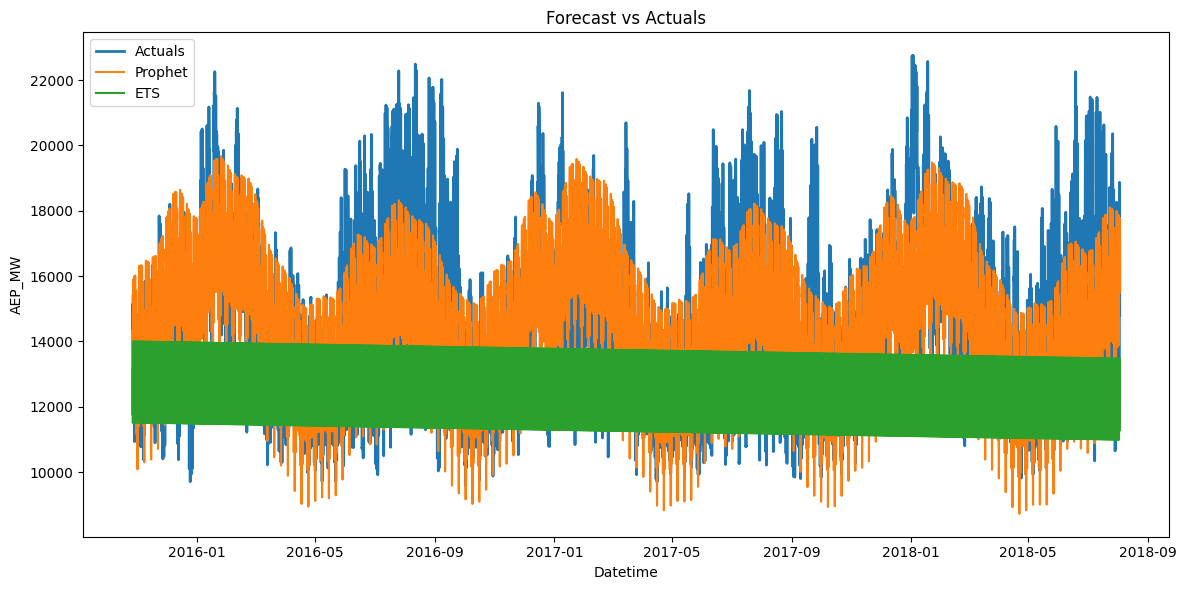

In [9]:
# Forecast Plot

plt.figure(figsize=(12, 6))
plt.plot(test_df.index, test_df[target_col], label="Actuals", linewidth=2)
plt.plot(preds1.index, preds1, label="Prophet")
plt.plot(preds2.index, preds2, label="ETS")
plt.title("Forecast vs Actuals")
plt.xlabel("Datetime")
plt.ylabel("AEP_MW")
plt.legend()
plt.tight_layout()
plt.show()


The residual plot shows the difference between the actual values and the forecasts. Prophet residuals stay closer to zero than ETS residuals most of the time, which means Prophet is generally more accurate. ETS residuals are often much larger and more positive, which means ETS tends to underpredict the demand.

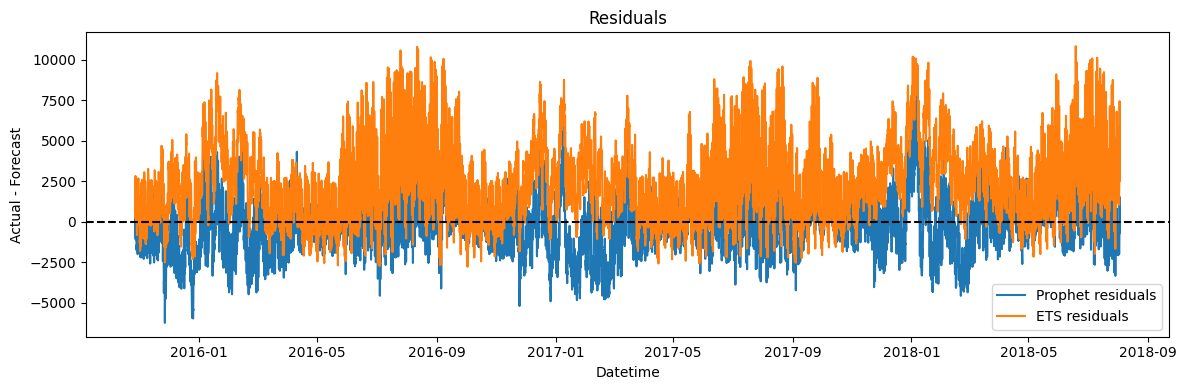

In [10]:
# Residual plot & saving the results

residuals1 = test_df[target_col] - preds1
residuals2 = test_df[target_col] - preds2

plt.figure(figsize=(12, 4))
plt.plot(residuals1.index, residuals1, label="Prophet residuals")
plt.plot(residuals2.index, residuals2, label="ETS residuals")
plt.axhline(0, color="black", linestyle="--")
plt.title("Residuals")
plt.xlabel("Datetime")
plt.ylabel("Actual - Forecast")
plt.legend()
plt.tight_layout()
plt.show()

#results.to_csv("data/session2_results.csv")


This plot compares the actual electricity demand with the two forecasts. The blue line is the real demand, the orange line is Prophet, and the green line is ETS. Prophet follows the overall seasonal up-and-down pattern better than ETS, but it still misses some of the sharper peaks and dips.

For this dataset and this split, Prophet is the stronger model because it follows the demand pattern more closely and produces smaller forecast errors.


In [12]:
comparison = pd.DataFrame({
    "Actual": test_df[target_col],
    "Prophet_Forecast": preds1,
    "ETS_Forecast": preds2
})

comparison.to_csv("data/session02_forecasts.csv")
results.to_csv("data/session02_results.csv")
